# Criminalidade em Grandes Cidades Brasileiras — Análise Exploratória

**Disciplina:** Linguagens de Programação — Análise e Visualização de Dados com Python
**Professor:** Alexandre Neves Louzada
**Aluno:** João Victor Gomes Teixeira
**Avaliação:** G1 — Tema 15

## 1. Introdução ao problema

A segurança pública é uma das maiores preocupações da população das grandes cidades brasileiras.
Entender **onde**, **quando** e **que tipo** de crime ocorre é essencial para direcionar policiamento,
políticas sociais e investimentos.

**Perguntas que este estudo busca responder:**
1. Quais regiões, estados e cidades concentram mais ocorrências?
2. Quais tipos de crime são mais frequentes e quais geram mais vítimas?
3. Há diferença entre períodos do dia e tipos de bairro?
4. Como a criminalidade evoluiu entre 2015 e 2024? Existe sazonalidade mensal?
5. A renda média ou o índice de violência têm relação com o volume de ocorrências e prisões?
6. Qual a eficiência policial medida pela taxa de prisões por ocorrência?

## 2. Explicação da base de dados

Arquivo `simulacao_criminalidade_brasil.csv` — **4.440 linhas × 15 colunas**. Base **simulada** para fins didáticos.

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Referência temporal mensal (jan/2015 a dez/2024) |
| `regiao`, `uf`, `cidade` | Localização (5 regiões, 20 UFs, 37 cidades) |
| `bairro` | Tipo de área: Centro, Zona Norte, Zona Sul, Periferia |
| `tipo_crime` | Estelionato, Furto, Roubo, Tráfico, Homicídio, Violência doméstica |
| `periodo_dia` | Madrugada, Manhã, Tarde, Noite |
| `ocorrencias` | Quantidade de ocorrências registradas |
| `vitimas` | Quantidade de vítimas |
| `prisoes` | Quantidade de prisões efetuadas |
| `renda_media` | Renda média da área (R$) |
| `indice_violencia` | Índice sintético de violência (≈10 a 120) |
| `nivel_risco` | Classificação de risco: Baixo, Médio, Alto, Crítico |

Cada linha representa um **registro mensal de uma cidade**.

## 3. Leitura dos dados

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Funciona no VS Code (pasta notebooks/) e no Google Colab (clona o repositório automaticamente)
if "google.colab" in sys.modules:
    import subprocess
    if not Path("AtividadeG1").exists():
        subprocess.run(["git", "clone", "-q", "https://github.com/Teixeiras15-collab/AtividadeG1"], check=True)
    RAIZ = Path("AtividadeG1").resolve()
else:
    RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from database.banco import preparar, salvar_banco, ler_banco, CSV

IMG = RAIZ / "imagens"
IMG.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

df_bruto = pd.read_csv(CSV, encoding="utf-8-sig")
print(df_bruto.shape)
df_bruto.head()

(4440, 15)


,ano,mes,data,regiao,uf,cidade,bairro,tipo_crime,periodo_dia,ocorrencias,vitimas,prisoes,renda_media,indice_violencia,nivel_risco
0,2015,1,2015-01-01,Norte,AM,Manaus,Centro,Estelionato,Madrugada,42,6,5,2391.23,72.87,Médio
1,2015,1,2015-01-01,Norte,PA,Belém,Zona Norte,Furto,Noite,25,4,3,3126.24,85.27,Crítico
2,2015,1,2015-01-01,Norte,PA,Santarém,Periferia,Furto,Manhã,22,1,3,3315.82,73.02,Alto
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Zona Sul,Violência doméstica,Tarde,27,5,4,4076.73,106.82,Alto
4,2015,1,2015-01-01,Norte,TO,Palmas,Zona Sul,Estelionato,Madrugada,27,6,4,3494.94,60.85,Crítico


In [2]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ano               4440 non-null   int64  
 1   mes               4440 non-null   int64  
 2   data              4440 non-null   str    
 3   regiao            4440 non-null   str    
 4   uf                4440 non-null   str    
 5   cidade            4440 non-null   str    
 6   bairro            4440 non-null   str    
 7   tipo_crime        4440 non-null   str    
 8   periodo_dia       4440 non-null   str    
 9   ocorrencias       4440 non-null   int64  
 10  vitimas           4440 non-null   int64  
 11  prisoes           4440 non-null   int64  
 12  renda_media       4440 non-null   float64
 13  indice_violencia  4440 non-null   float64
 14  nivel_risco       4440 non-null   str    
dtypes: float64(2), int64(5), str(8)
memory usage: 780.4 KB


In [3]:
df_bruto.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ano,4440.0,2019.50,2.87,2015.00,2017.00,2019.50,2022.00,2024.00
mes,4440.0,6.50,3.45,1.00,3.75,6.50,9.25,12.00
ocorrencias,4440.0,29.92,5.43,14.00,26.00,30.00,33.00,53.00
vitimas,4440.0,5.00,2.25,0.00,3.00,5.00,6.00,16.00
prisoes,4440.0,2.98,1.72,0.00,2.00,3.00,4.00,12.00
renda_media,4440.0,2781.47,644.16,689.71,2357.45,2795.62,3209.48,5138.46
indice_violencia,4440.0,64.67,31.54,10.02,37.26,64.80,91.26,119.95


## 4. Limpeza e preparação

In [4]:
print("Valores nulos por coluna:\n", df_bruto.isna().sum(), sep="")
print("\nLinhas duplicadas:", df_bruto.duplicated().sum())
print("Valores negativos em contagens:", (df_bruto[["ocorrencias", "vitimas", "prisoes"]] < 0).sum().sum())

Valores nulos por coluna:
ano                 0
mes                 0
data                0
regiao              0
uf                  0
cidade              0
bairro              0
tipo_crime          0
periodo_dia         0
ocorrencias         0
vitimas             0
prisoes             0
renda_media         0
indice_violencia    0
nivel_risco         0
dtype: int64

Linhas duplicadas: 0
Valores negativos em contagens: 0


In [5]:
# Consistência das categorias
for col in ["regiao", "uf", "bairro", "tipo_crime", "periodo_dia", "nivel_risco"]:
    print(f"{col:12s} ->", sorted(df_bruto[col].unique()))
print("cidades:", df_bruto["cidade"].nunique())
print("\nRegistros por ano:\n", df_bruto["ano"].value_counts().sort_index().to_dict())

regiao       -> ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
uf           -> ['AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PR', 'RJ', 'RO', 'RS', 'SC', 'SP', 'TO']
bairro       -> ['Centro', 'Periferia', 'Zona Norte', 'Zona Sul']
tipo_crime   -> ['Estelionato', 'Furto', 'Homicídio', 'Roubo', 'Tráfico', 'Violência doméstica']
periodo_dia  -> ['Madrugada', 'Manhã', 'Noite', 'Tarde']
nivel_risco  -> ['Alto', 'Baixo', 'Crítico', 'Médio']
cidades: 37

Registros por ano:
 {2015: 444, 2016: 444, 2017: 444, 2018: 444, 2019: 444, 2020: 444, 2021: 444, 2022: 444, 2023: 444, 2024: 444}


In [6]:
# Outliers (regra do IQR) nas variáveis numéricas
num = ["ocorrencias", "vitimas", "prisoes", "renda_media", "indice_violencia"]
q1, q3 = df_bruto[num].quantile(0.25), df_bruto[num].quantile(0.75)
iqr = q3 - q1
outliers = ((df_bruto[num] < q1 - 1.5 * iqr) | (df_bruto[num] > q3 + 1.5 * iqr)).sum()
outliers.to_frame("qtd_outliers")

,qtd_outliers
ocorrencias,46
vitimas,56
prisoes,38
renda_media,33
indice_violencia,0


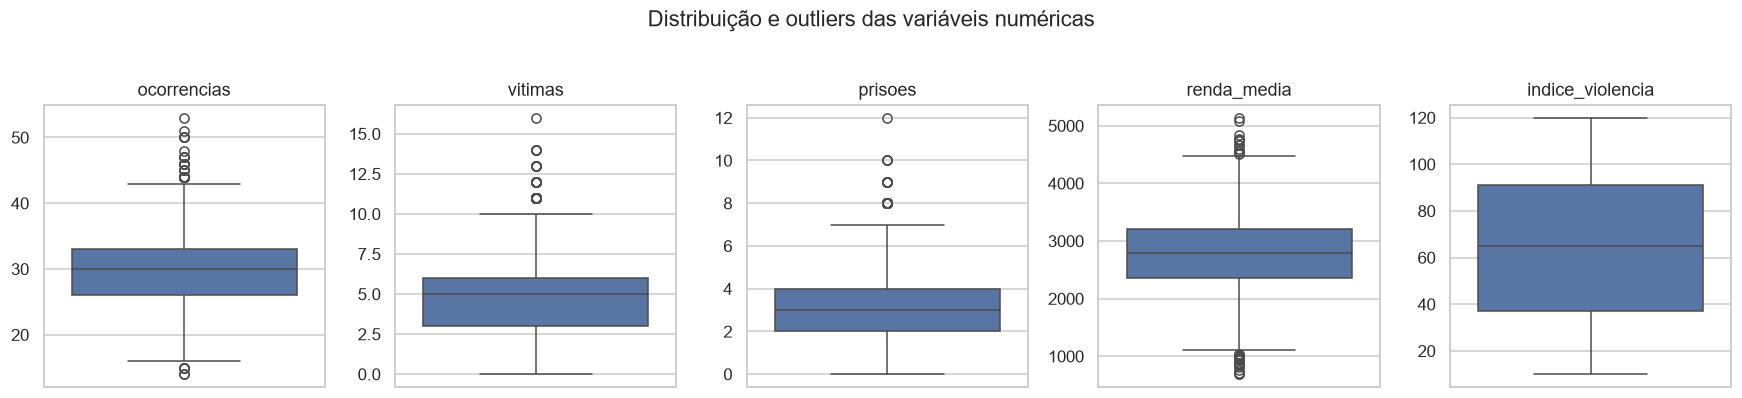

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, col in zip(axes, num):
    sns.boxplot(y=df_bruto[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_ylabel("")
plt.suptitle("Distribuição e outliers das variáveis numéricas", y=1.03)
plt.tight_layout()
plt.savefig(IMG / "01_boxplots.png", bbox_inches="tight")
plt.show()

**Diagnóstico:** a base não possui nulos, duplicatas nem valores negativos. Os poucos outliers
detectados pelo IQR são valores plausíveis (meses com mais ocorrências/vítimas) e foram **mantidos**,
pois representam eventos reais e não erros de digitação.

**Tratamentos aplicados** (função `preparar` em `database/banco.py`):
- padronização de nomes de colunas e remoção de espaços nos textos;
- conversão de `data` para `datetime`;
- remoção de duplicatas e de contagens negativas (garantia para atualizações futuras da base).

## 5. Engenharia de atributos

Novas colunas criadas:
- **`trimestre`** — trimestre do ano, para análises sazonais;
- **`taxa_prisao`** — prisões ÷ ocorrências (proxy de eficiência policial);
- **`vitimas_por_ocorrencia`** — gravidade média das ocorrências;
- **`faixa_renda`** — quartis de renda média (Baixa, Média-baixa, Média-alta, Alta).

In [8]:
df = preparar(df_bruto)
df[["data", "cidade", "ocorrencias", "prisoes", "taxa_prisao", "vitimas_por_ocorrencia", "renda_media", "faixa_renda", "trimestre"]].head()

,data,cidade,ocorrencias,prisoes,taxa_prisao,vitimas_por_ocorrencia,renda_media,faixa_renda,trimestre
0,2015-01-01,Manaus,42,5,0.1190,0.1429,2391.23,Média-baixa,1
1,2015-01-01,Belém,25,3,0.1200,0.1600,3126.24,Média-alta,1
2,2015-01-01,Santarém,22,3,0.1364,0.0455,3315.82,Alta,1
3,2015-01-01,Porto Velho,27,4,0.1481,0.1852,4076.73,Alta,1
4,2015-01-01,Palmas,27,4,0.1481,0.2222,3494.94,Alta,1


### Persistência em banco (SQLAlchemy + SQLite)

A base tratada é gravada em `database/criminalidade.db` com **modelagem relacional**:
uma tabela dimensão `cidades` (com UF, região e coordenadas geográficas) e uma tabela fato
`ocorrencias` ligada por chave estrangeira `cidade_id`. O dashboard Streamlit lê os dados
deste banco por meio de um `JOIN`.

In [9]:
salvar_banco(df)
df_db = ler_banco()
print(df_db.shape)
df_db[["cidade", "uf", "regiao", "lat", "lon", "tipo_crime", "ocorrencias"]].head()

(4440, 21)


,cidade,uf,regiao,lat,lon,tipo_crime,ocorrencias
0,Manaus,AM,Norte,-3.119,-60.022,Estelionato,42
1,Belém,PA,Norte,-1.456,-48.490,Furto,25
2,Santarém,PA,Norte,-2.443,-54.708,Furto,22
3,Porto Velho,RO,Norte,-8.761,-63.900,Violência doméstica,27
4,Palmas,TO,Norte,-10.184,-48.333,Estelionato,27


## 6. Análise exploratória

In [10]:
def resumo(col):
    g = df.groupby(col).agg(ocorrencias=("ocorrencias", "sum"), vitimas=("vitimas", "sum"),
                            prisoes=("prisoes", "sum"), media_mensal=("ocorrencias", "mean"),
                            indice_violencia=("indice_violencia", "mean"))
    g["taxa_prisao_%"] = 100 * g["prisoes"] / g["ocorrencias"]
    g["participacao_%"] = 100 * g["ocorrencias"] / g["ocorrencias"].sum()
    return g.sort_values("ocorrencias", ascending=False).round(2)

resumo("regiao")

,ocorrencias,vitimas,prisoes,media_mensal,indice_violencia,taxa_prisao_%,participacao_%
regiao,,,,,,,
Sudeste,46637,7847,4645,29.90,65.09,9.96,35.11
Nordeste,28781,4773,2903,29.98,63.73,10.09,21.67
Sul,21504,3618,2156,29.87,63.97,10.03,16.19
Centro-Oeste,18115,2981,1754,30.19,64.80,9.68,13.64
Norte,17808,3001,1761,29.68,65.79,9.89,13.41


In [11]:
resumo("tipo_crime")

,ocorrencias,vitimas,prisoes,media_mensal,indice_violencia,taxa_prisao_%,participacao_%
tipo_crime,,,,,,,
Roubo,23440,3966,2283,29.94,66.32,9.74,17.64
Tráfico,23337,3888,2279,30.19,64.92,9.77,17.57
Estelionato,21887,3565,2230,29.74,64.86,10.19,16.48
Violência doméstica,21505,3590,2191,29.79,63.97,10.19,16.19
Homicídio,21497,3698,2111,29.94,64.64,9.82,16.18
Furto,21179,3513,2125,29.91,63.13,10.03,15.94


In [12]:
resumo("periodo_dia")

,ocorrencias,vitimas,prisoes,media_mensal,indice_violencia,taxa_prisao_%,participacao_%
periodo_dia,,,,,,,
Tarde,33957,5671,3392,29.94,64.34,9.99,25.56
Madrugada,33760,5710,3314,29.85,65.64,9.82,25.41
Manhã,32930,5521,3269,29.83,64.03,9.93,24.79
Noite,32198,5318,3244,30.06,64.67,10.08,24.24


In [13]:
resumo("bairro")

,ocorrencias,vitimas,prisoes,media_mensal,indice_violencia,taxa_prisao_%,participacao_%
bairro,,,,,,,
Zona Sul,34212,5647,3400,30.17,65.54,9.94,25.75
Periferia,33447,5595,3295,30.00,65.07,9.85,25.18
Centro,33121,5667,3261,29.84,63.63,9.85,24.93
Zona Norte,32065,5311,3263,29.66,64.42,10.18,24.14


In [14]:
print("Cidades por região:", df.groupby("regiao")["cidade"].nunique().to_dict())
print("\nTop 5 cidades em ocorrências:")
print(resumo("cidade").head(5)[["ocorrencias", "indice_violencia", "taxa_prisao_%"]])
print("\n5 cidades com menos ocorrências:")
print(resumo("cidade").tail(5)[["ocorrencias", "indice_violencia", "taxa_prisao_%"]])

Cidades por região: {'Centro-Oeste': 5, 'Nordeste': 8, 'Norte': 5, 'Sudeste': 13, 'Sul': 6}

Top 5 cidades em ocorrências:
                ocorrencias  indice_violencia  taxa_prisao_%
cidade                                                      
Florianópolis          3707             59.58           9.71
Goiânia                3672             61.23           9.72
Brasília               3670             63.63           9.40
Belo Horizonte         3665             66.70           9.25
Petrópolis             3664             66.09          10.21

5 cidades com menos ocorrências:
               ocorrencias  indice_violencia  taxa_prisao_%
cidade                                                     
São Paulo             3523             63.20           9.37
Porto Velho           3516             70.46          10.49
Caxias do Sul         3510             69.32          10.14
Nova Iguaçu           3505             67.13          10.13
Belém                 3486             62.41           9

In [15]:
# Coerência entre nível de risco e índice de violência
df.groupby("nivel_risco")["indice_violencia"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
nivel_risco,,,,,,,,
Alto,1126.0,64.39,31.61,10.07,37.37,63.40,91.47,119.95
Baixo,1106.0,65.03,30.90,10.04,38.66,64.77,91.24,119.76
Crítico,1137.0,65.19,31.84,10.06,37.71,65.04,92.51,119.85
Médio,1071.0,64.05,31.84,10.02,35.87,65.20,89.87,119.88


**Observação importante:** o `nivel_risco` **não acompanha** o `indice_violencia` — todas as classes
cobrem praticamente toda a faixa de 10 a 120. Em uma base real isso indicaria uma classificação
inconsistente; aqui é reflexo da natureza simulada dos dados.

## 7. KPIs

In [16]:
anos = df.groupby("ano")["ocorrencias"].sum()
kpis = {
    "Total de ocorrências": f"{df['ocorrencias'].sum():,}".replace(",", "."),
    "Total de vítimas": f"{df['vitimas'].sum():,}".replace(",", "."),
    "Total de prisões": f"{df['prisoes'].sum():,}".replace(",", "."),
    "Taxa de prisão (prisões/ocorrências)": f"{df['prisoes'].sum() / df['ocorrencias'].sum():.1%}",
    "Vítimas por ocorrência": f"{df['vitimas'].sum() / df['ocorrencias'].sum():.3f}",
    "Média mensal de ocorrências por cidade": f"{df['ocorrencias'].mean():.1f}",
    "Índice de violência médio": f"{df['indice_violencia'].mean():.1f}",
    "Variação 2015 → 2024": f"{anos.iloc[-1] / anos.iloc[0] - 1:+.2%}",
    "Crime mais frequente": df.groupby("tipo_crime")["ocorrencias"].sum().idxmax(),
    "Cidade com mais ocorrências": df.groupby("cidade")["ocorrencias"].sum().idxmax(),
}
pd.Series(kpis, name="valor").to_frame()

,valor
Total de ocorrências,132.845
Total de vítimas,22.220
Total de prisões,13.219
Taxa de prisão (prisões/ocorrências),10.0%
Vítimas por ocorrência,0.167
Média mensal de ocorrências por cidade,29.9
Índice de violência médio,64.7
Variação 2015 → 2024,-0.11%
Crime mais frequente,Roubo
Cidade com mais ocorrências,Florianópolis


## 8. Gráficos

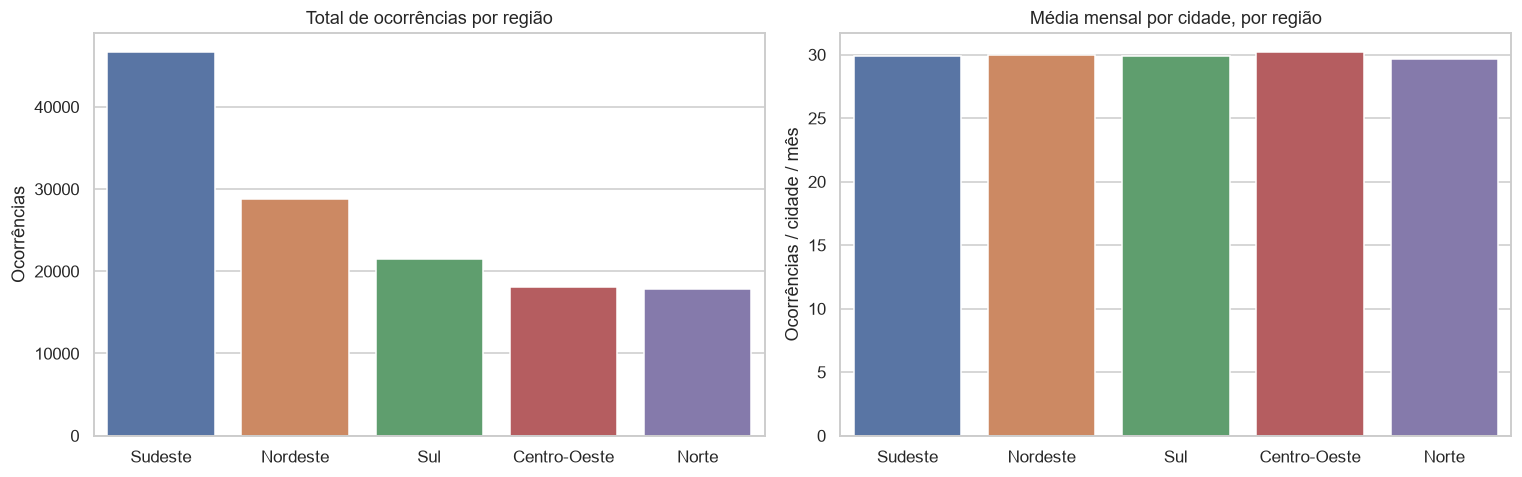

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
r = resumo("regiao")
sns.barplot(x=r.index, y=r["ocorrencias"], ax=axes[0], hue=r.index, legend=False)
axes[0].set_title("Total de ocorrências por região")
axes[0].set_xlabel(""); axes[0].set_ylabel("Ocorrências")
sns.barplot(x=r.index, y=r["media_mensal"], ax=axes[1], hue=r.index, legend=False)
axes[1].set_title("Média mensal por cidade, por região")
axes[1].set_xlabel(""); axes[1].set_ylabel("Ocorrências / cidade / mês")
plt.tight_layout()
plt.savefig(IMG / "02_regiao.png", bbox_inches="tight")
plt.show()

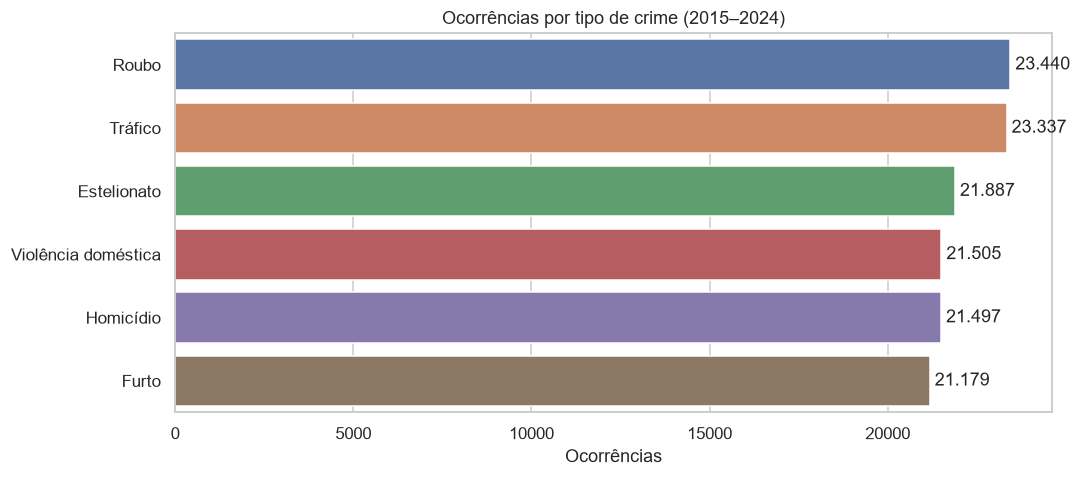

In [18]:
t = resumo("tipo_crime")
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(y=t.index, x=t["ocorrencias"], ax=ax, hue=t.index, legend=False)
for i, v in enumerate(t["ocorrencias"]):
    ax.text(v, i, f" {v:,}".replace(",", "."), va="center")
ax.set_title("Ocorrências por tipo de crime (2015–2024)")
ax.set_xlabel("Ocorrências"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(IMG / "03_tipo_crime.png", bbox_inches="tight")
plt.show()

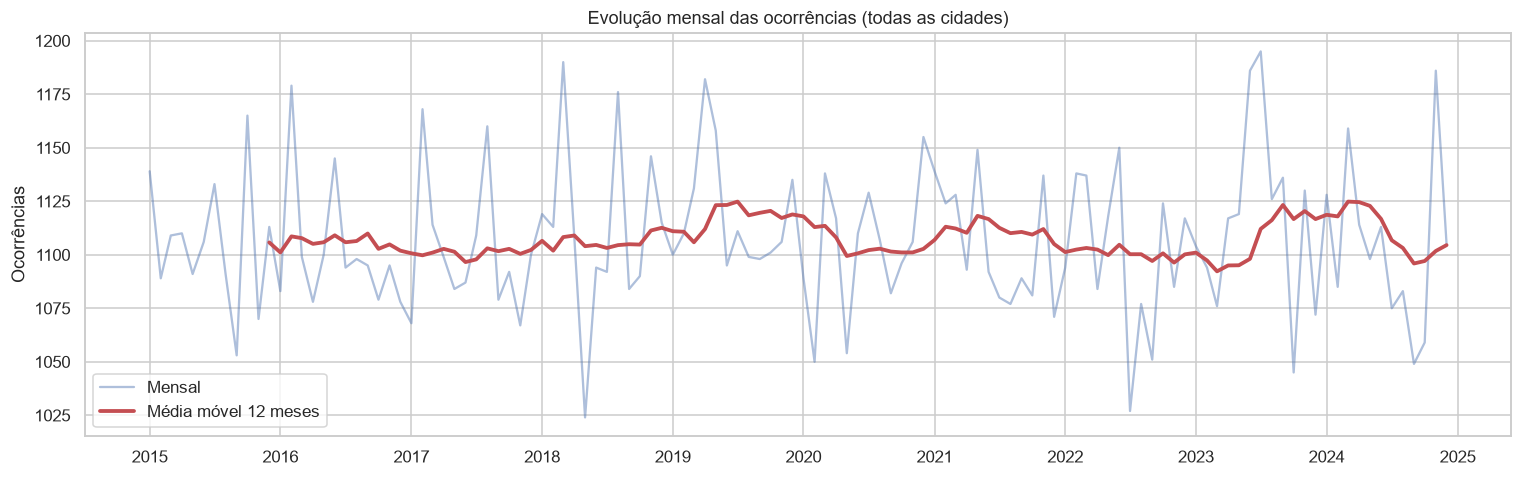

In [19]:
serie = df.groupby("data")["ocorrencias"].sum()
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(serie.index, serie.values, alpha=0.45, label="Mensal")
ax.plot(serie.index, serie.rolling(12).mean(), lw=2.5, color="#C44E52", label="Média móvel 12 meses")
ax.set_title("Evolução mensal das ocorrências (todas as cidades)")
ax.set_ylabel("Ocorrências"); ax.legend()
plt.tight_layout()
plt.savefig(IMG / "04_serie_temporal.png", bbox_inches="tight")
plt.show()

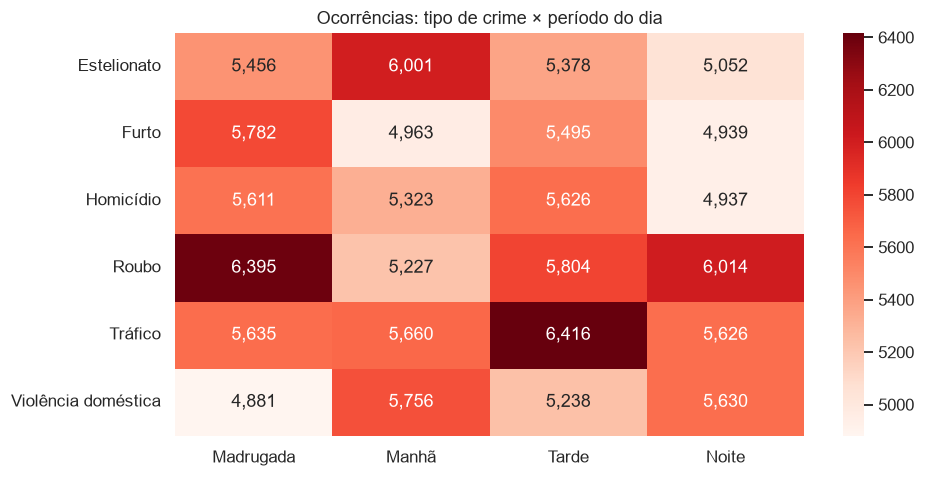

In [20]:
pivot = df.pivot_table(index="tipo_crime", columns="periodo_dia", values="ocorrencias", aggfunc="sum")
pivot = pivot[["Madrugada", "Manhã", "Tarde", "Noite"]]
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pivot, annot=True, fmt=",d", cmap="Reds", ax=ax)
ax.set_title("Ocorrências: tipo de crime × período do dia")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(IMG / "05_heatmap_crime_periodo.png", bbox_inches="tight")
plt.show()

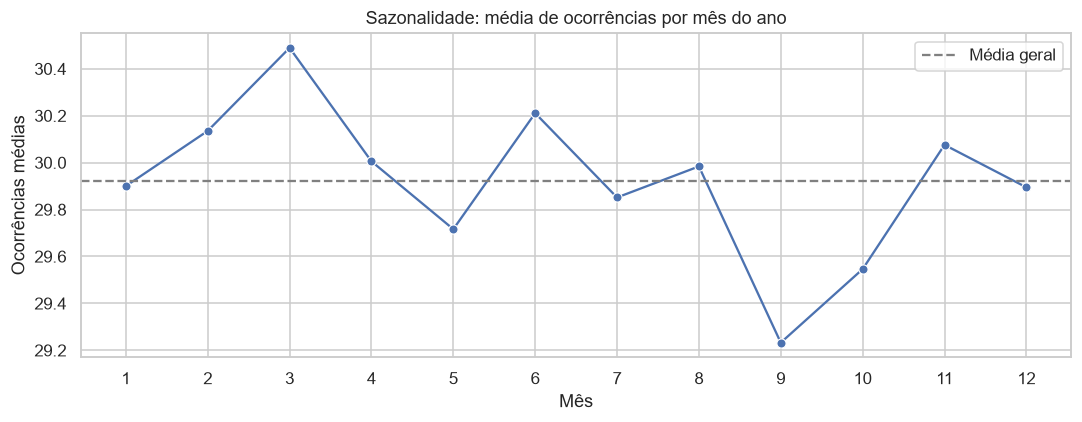

In [21]:
sazonal = df.groupby("mes")["ocorrencias"].mean()
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(x=sazonal.index, y=sazonal.values, marker="o", ax=ax)
ax.axhline(df["ocorrencias"].mean(), ls="--", color="gray", label="Média geral")
ax.set_xticks(range(1, 13))
ax.set_title("Sazonalidade: média de ocorrências por mês do ano")
ax.set_xlabel("Mês"); ax.set_ylabel("Ocorrências médias"); ax.legend()
plt.tight_layout()
plt.savefig(IMG / "06_sazonalidade.png", bbox_inches="tight")
plt.show()

### Correlação estatística

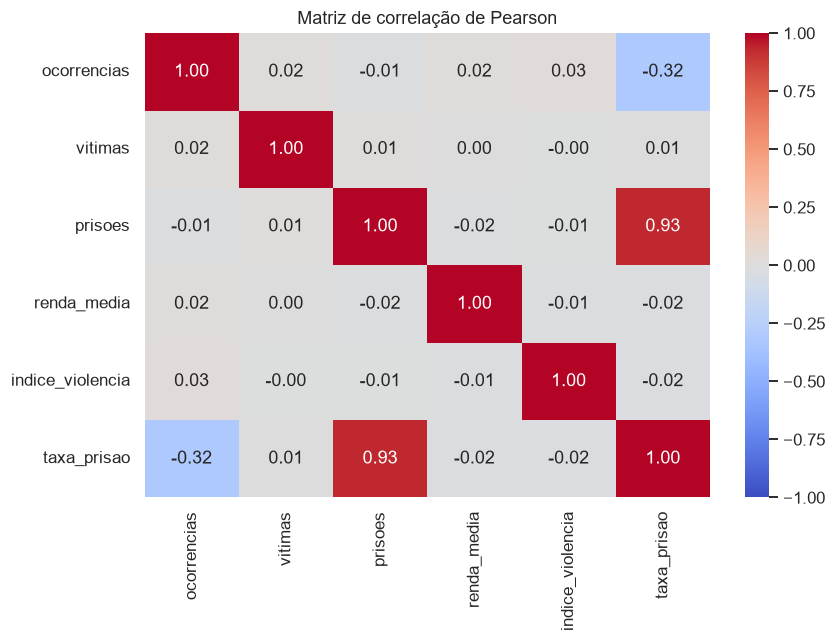

In [22]:
cols = ["ocorrencias", "vitimas", "prisoes", "renda_media", "indice_violencia", "taxa_prisao"]
corr = df[cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlação de Pearson")
plt.tight_layout()
plt.savefig(IMG / "07_correlacao.png", bbox_inches="tight")
plt.show()

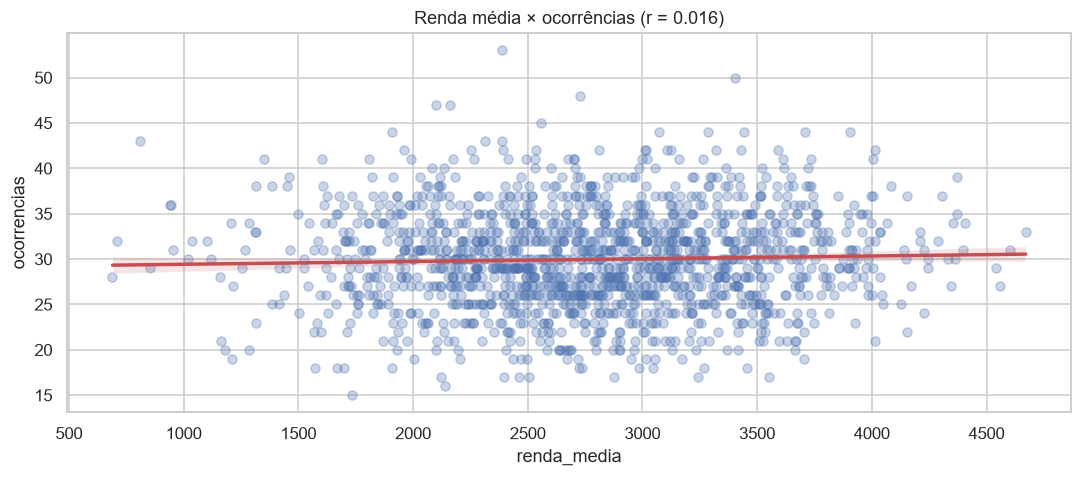

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.regplot(data=df.sample(1500, random_state=42), x="renda_media", y="ocorrencias",
            scatter_kws={"alpha": 0.3}, line_kws={"color": "#C44E52"}, ax=ax)
ax.set_title(f"Renda média × ocorrências (r = {df['renda_media'].corr(df['ocorrencias']):.3f})")
plt.tight_layout()
plt.savefig(IMG / "08_renda_ocorrencias.png", bbox_inches="tight")
plt.show()

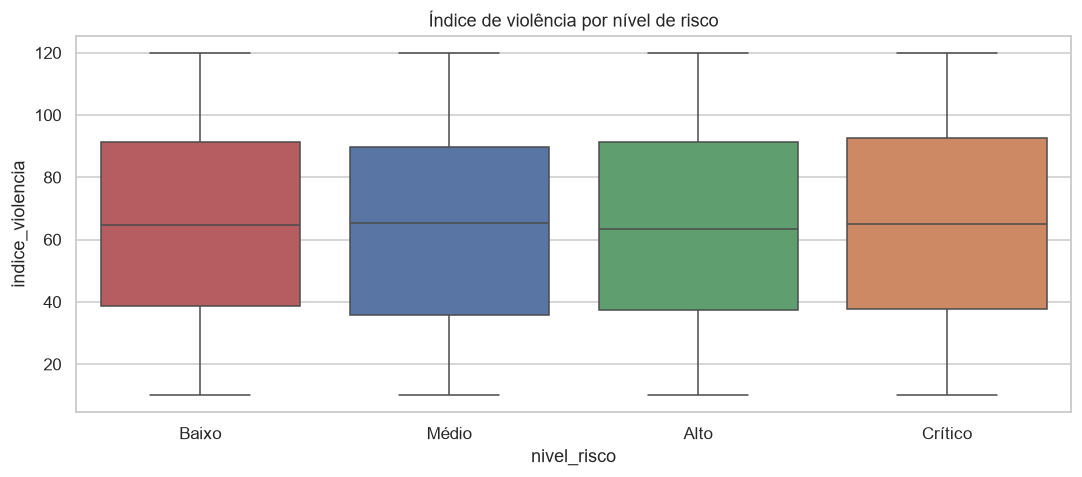

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df, x="nivel_risco", y="indice_violencia", order=["Baixo", "Médio", "Alto", "Crítico"], ax=ax,
            hue="nivel_risco", legend=False)
ax.set_title("Índice de violência por nível de risco")
plt.tight_layout()
plt.savefig(IMG / "09_risco_indice.png", bbox_inches="tight")
plt.show()

## 9. Interpretação dos resultados

- **Concentração geográfica:** o Sudeste soma o maior volume (~35% das ocorrências), mas isso se deve ao
  maior número de cidades na amostra (13 de 37). Quando normalizamos por cidade/mês, todas as regiões ficam
  próximas de **30 ocorrências/mês** — ou seja, a diferença é de escala, não de intensidade.
- **Tipos de crime:** **Roubo** e **Tráfico** lideram em volume, seguidos de perto por estelionato, violência
  doméstica, homicídio e furto. A distribuição é equilibrada (cada tipo entre 16% e 18%).
- **Período do dia e bairro:** a **Tarde** e a **Madrugada** concentram levemente mais ocorrências; entre os
  bairros, a **Zona Sul** aparece à frente. As diferenças, porém, são pequenas (< 6%).
- **Crime × período:** o mapa de calor mostra padrões específicos — **Roubo** concentra-se na **madrugada**,
  **Tráfico** na **tarde** e **Estelionato** na **manhã** (horário comercial), enquanto Violência doméstica é menor na madrugada.
- **Evolução temporal:** a série 2015–2024 é praticamente **estável** (variação total próxima de 0%), sem
  tendência clara de alta ou queda; a média móvel de 12 meses oscila pouco. Não há sazonalidade forte
  — setembro e outubro estão um pouco abaixo da média.
- **Eficiência policial:** a taxa de prisão é de aproximadamente **10%** — apenas 1 prisão a cada 10 ocorrências,
  um indicador baixo e homogêneo entre regiões.
- **Correlações:** renda média, índice de violência, vítimas e prisões apresentam correlação **próxima de zero**
  com o número de ocorrências. Nesta base, renda não explica criminalidade.
- **Qualidade da classificação:** o `nivel_risco` não é coerente com o `indice_violencia` — cada nível cobre
  toda a faixa do índice. Esse campo não deveria ser usado isoladamente para tomada de decisão.

## 10. Conclusão

A análise mostrou uma criminalidade **distribuída de forma homogênea** entre regiões, cidades, tipos de crime e
períodos, com volume estável ao longo de dez anos e baixa taxa de prisões (~10%). As maiores somas observadas
(Sudeste, Roubo, Tarde) são explicadas principalmente pelo número de registros e não por uma intensidade maior.

Como a base é **simulada**, as relações fracas (renda × crime, nível de risco × índice) são esperadas e servem
como alerta metodológico: **sempre normalizar** os indicadores (por cidade, por mês, por habitante) antes de
comparar e **validar classificações** derivadas antes de usá-las.

**Recomendações:** priorizar ações que elevem a taxa de prisão, monitorar Roubo e Tráfico (maiores volumes)
e, em estudos com dados reais, incorporar população e área para calcular taxas por 100 mil habitantes.

O dashboard interativo em Streamlit (`app.py`) permite explorar estes resultados com filtros dinâmicos,
mapa interativo e KPIs recalculados em tempo real.